KPI and Trend Analysis

In [27]:
import pandas as pd

df = pd.read_csv("../data/sme_gym_sales_2015_2025-1.csv")

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

jan_2015 = df[
    (df["transaction_date"] >= "2015-01-01") &
    (df["transaction_date"] < "2015-02-01")
]

dec_2025 = df[
    (df["transaction_date"] >= "2025-12-01") &
    (df["transaction_date"] < "2026-01-01")
]

def percentage_change(current, baseline):
    return ((current - baseline) / baseline) * 100

In [28]:
# KPI 1: Total Net Revenue
current = dec_2025["net_revenue_gbp"].sum()
baseline = jan_2015["net_revenue_gbp"].sum()

print(f"Current: £{current:,.2f}")
print(f"January 2015: £{baseline:,.2f}")
print(f"Change: {percentage_change(current, baseline):.1f}%")

Current: £30,040.08
January 2015: £7,090.84
Change: 323.6%


In [29]:
# KPI 2: Average Net Revenue per Transaction
current = dec_2025["net_revenue_gbp"].mean()
baseline = jan_2015["net_revenue_gbp"].mean()

print(f"Current: £{current:,.2f}")
print(f"January 2015: £{baseline:,.2f}")
print(f"Change: {percentage_change(current, baseline):.1f}%")

Current: £202.97
January 2015: £112.55
Change: 80.3%


In [30]:
# KPI 3: Corporate Customer Segment
current = dec_2025.loc[
    dec_2025["customer_segment"] == "Corporate",
    "net_revenue_gbp"
].sum()

baseline = jan_2015.loc[
    jan_2015["customer_segment"] == "Corporate",
    "net_revenue_gbp"
].sum()

print(f"Current: £{current:,.2f}")
print(f"January 2015: £{baseline:,.2f}")
print(f"Change: {percentage_change(current, baseline):.1f}%")

Current: £6,944.97
January 2015: £1,405.22
Change: 394.2%


In [31]:
# KPI 4: Northside Branch
current = dec_2025.loc[
    dec_2025["branch"] == "Northside",
    "net_revenue_gbp"
].sum()

baseline = jan_2015.loc[
    jan_2015["branch"] == "Northside",
    "net_revenue_gbp"
].sum()

print(f"Current: £{current:,.2f}")
print(f"January 2015: £{baseline:,.2f}")
print(f"Change: {percentage_change(current, baseline):.1f}%")

Current: £8,253.10
January 2015: £1,711.06
Change: 382.3%


Line Chart (Anomaly Detection And Forecasting)

In [32]:
import matplotlib.pyplot as plt

monthly = (
    df
    .set_index("transaction_date")
    .resample("MS")["net_revenue_gbp"]
    .sum()
    .reset_index()
)

monthly.head()

,transaction_date,net_revenue_gbp
0,2015-01-01,7090.84
1,2015-02-01,8368.27
2,2015-03-01,6205.30
3,2015-04-01,5770.70
4,2015-05-01,7999.62


,transaction_date,net_revenue_gbp
108,2024-01-01,38037.50
120,2025-01-01,61321.68
121,2025-02-01,35454.56
128,2025-09-01,38898.90


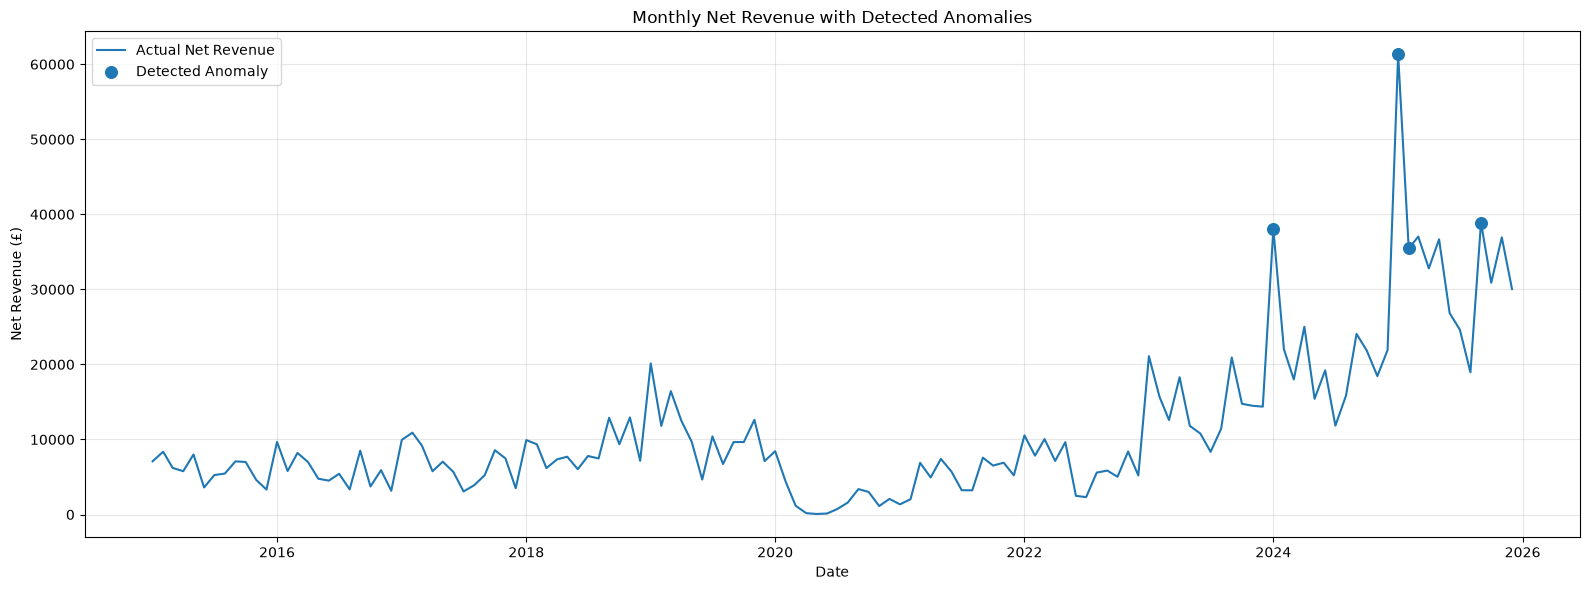

In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.025,
    random_state=42
)

monthly["anomaly"] = model.fit_predict(
    monthly[["net_revenue_gbp"]]
)

anomalies = anomalies[
    ["transaction_date", "net_revenue_gbp"]
].sort_values("transaction_date")

display(anomalies)

plt.figure(figsize=(16, 6))

plt.plot(
    monthly["transaction_date"],
    monthly["net_revenue_gbp"],
    label="Actual Net Revenue"
)

plt.scatter(
    anomalies["transaction_date"],
    anomalies["net_revenue_gbp"],
    marker="o",
    s=70,
    label="Detected Anomaly",
    zorder=5
)

plt.xlabel("Date")
plt.ylabel("Net Revenue (£)")
plt.title("Monthly Net Revenue with Detected Anomalies")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 3824.76it/s]


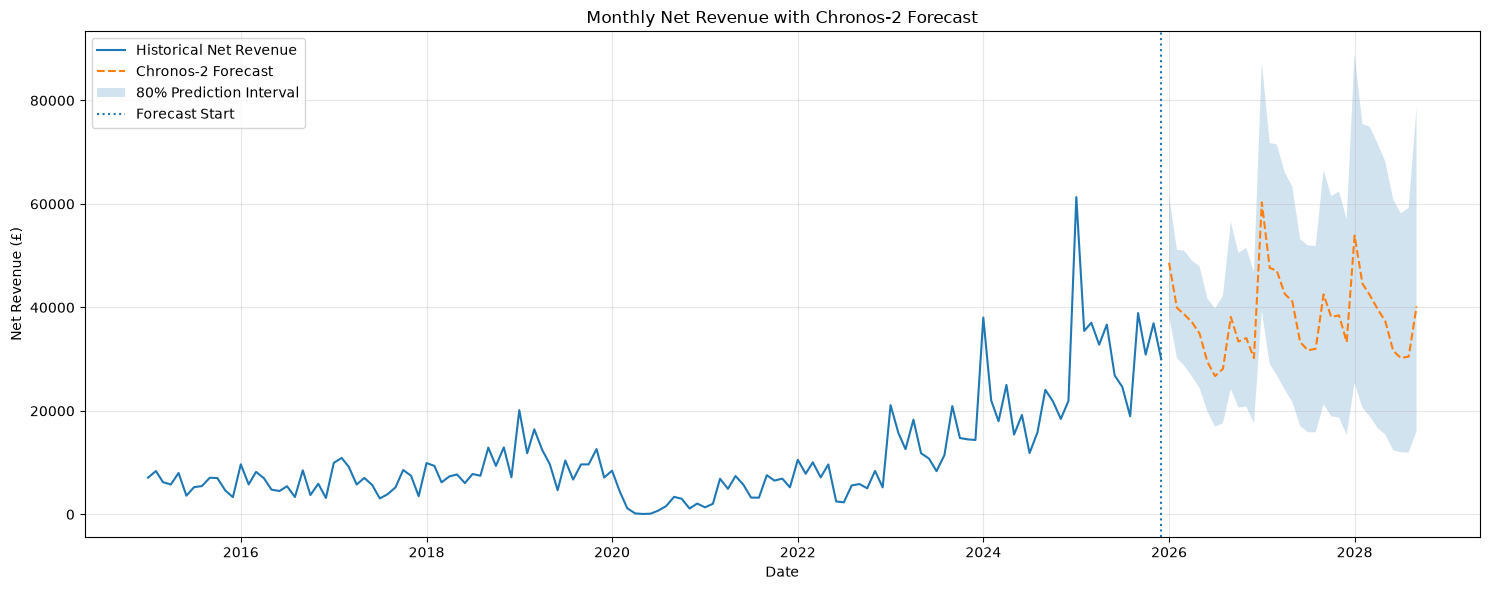

,Month,Forecast (£),Lower 10% (£),Median 50% (£),Upper 90% (£)
0,Jan 2026,48598.761719,38366.101562,48598.761719,61645.859375
1,Feb 2026,39908.789062,30200.580078,39908.789062,51116.039062
2,Mar 2026,38675.601562,28759.169922,38675.601562,50974.019531
3,Apr 2026,37139.589844,26685.160156,37139.589844,49041.359375
4,May 2026,34938.671875,24402.939453,34938.671875,47950.011719


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

monthly = (
    df.set_index("transaction_date")
      .resample("MS")["net_revenue_gbp"]
      .sum()
      .reset_index()
)

context_df = monthly.rename(columns={
    "transaction_date": "timestamp",
    "net_revenue_gbp": "target"
})

context_df["id"] = "net_revenue"
context_df = context_df[["id", "timestamp", "target"]]

prediction_length = round(len(context_df) * 0.25)

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map="cpu"
)

forecast_df = pipeline.predict_df(
    context_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target"
)

forecast_df["timestamp"] = pd.to_datetime(forecast_df["timestamp"])

plt.figure(figsize=(15, 6))

plt.plot(
    context_df["timestamp"],
    context_df["target"],
    label="Historical Net Revenue"
)

plt.plot(
    forecast_df["timestamp"],
    forecast_df["predictions"],
    linestyle="--",
    label="Chronos-2 Forecast"
)

plt.fill_between(
    forecast_df["timestamp"],
    forecast_df["0.1"],
    forecast_df["0.9"],
    alpha=0.2,
    label="80% Prediction Interval"
)

plt.axvline(
    context_df["timestamp"].max(),
    linestyle=":",
    label="Forecast Start"
)

plt.title("Monthly Net Revenue with Chronos-2 Forecast")
plt.xlabel("Date")
plt.ylabel("Net Revenue (£)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

forecast_table = forecast_df[
    ["timestamp", "predictions", "0.1", "0.5", "0.9"]
].copy()

forecast_table.columns = [
    "Month",
    "Forecast (£)",
    "Lower 10% (£)",
    "Median 50% (£)",
    "Upper 90% (£)"
]

forecast_table["Month"] = forecast_table["Month"].dt.strftime("%b %Y")

for col in forecast_table.columns[1:]:
    forecast_table[col] = forecast_table[col].round(2)

display(forecast_table.head())

Other Charts

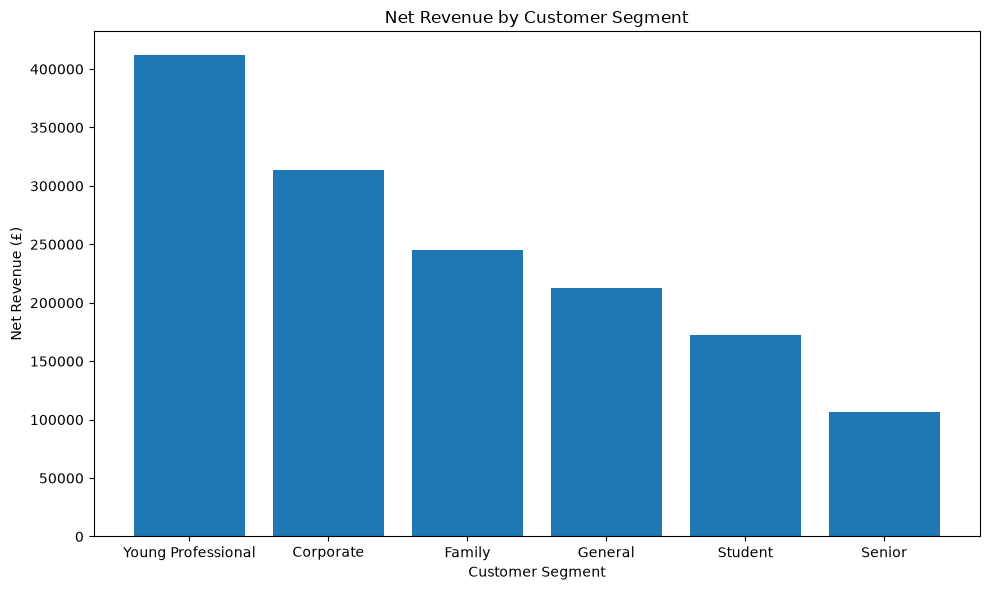

,customer_segment,net_revenue_gbp
5,Young Professional,411684.25
0,Corporate,313203.63
1,Family,245245.92
2,General,212806.98
4,Student,172210.13
3,Senior,106437.52


In [ ]:
segment_rev = (
    df.groupby("customer_segment", as_index=False)["net_revenue_gbp"]
      .sum()
      .sort_values("net_revenue_gbp", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(segment_rev["customer_segment"], segment_rev["net_revenue_gbp"])
plt.title("Net Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Net Revenue (£)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

segment_rev

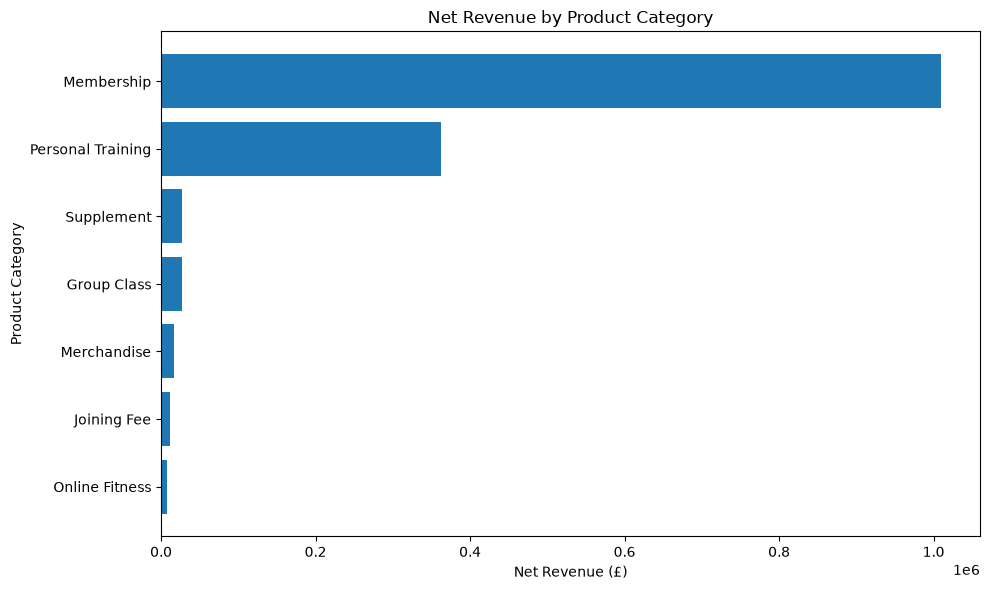

,product_category,net_revenue_gbp
2,Membership,1009591.43
5,Personal Training,362857.14
6,Supplement,26924.25
0,Group Class,26686.53
3,Merchandise,16204.09
1,Joining Fee,11350.64
4,Online Fitness,7974.35


In [22]:
category_rev = (
    df.groupby("product_category", as_index=False)["net_revenue_gbp"]
      .sum()
      .sort_values("net_revenue_gbp", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.barh(category_rev["product_category"], category_rev["net_revenue_gbp"])
plt.title("Net Revenue by Product Category")
plt.xlabel("Net Revenue (£)")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

category_rev

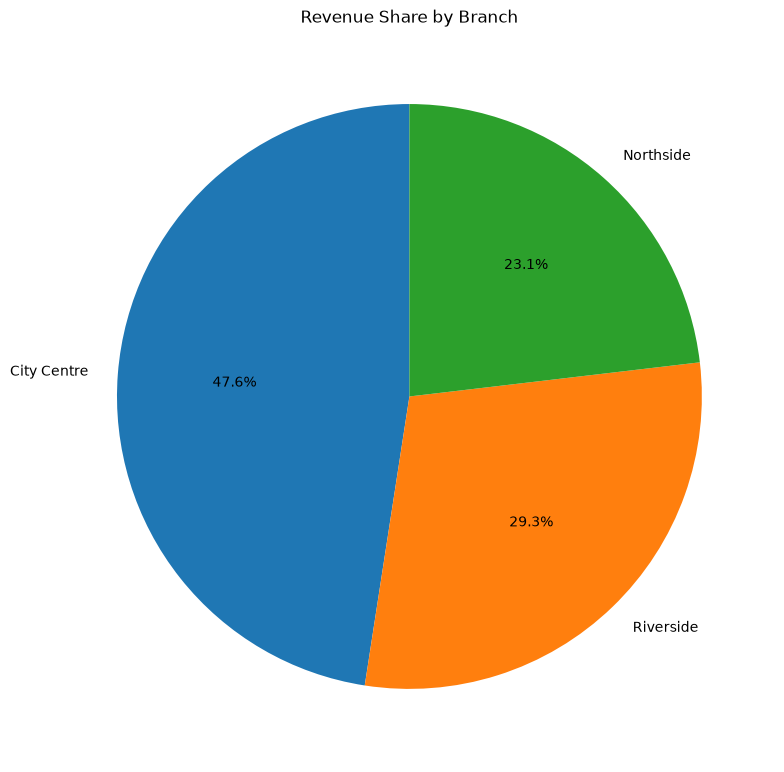

,branch,net_revenue_gbp
0,City Centre,695119.76
2,Riverside,428296.48
1,Northside,338172.19


In [25]:
branch_rev = (
    df.groupby("branch", as_index=False)["net_revenue_gbp"]
      .sum()
      .sort_values("net_revenue_gbp", ascending=False)
)

plt.figure(figsize=(8, 8))
plt.pie(
    branch_rev["net_revenue_gbp"],
    labels=branch_rev["branch"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue Share by Branch")
plt.tight_layout()
plt.show()

branch_rev

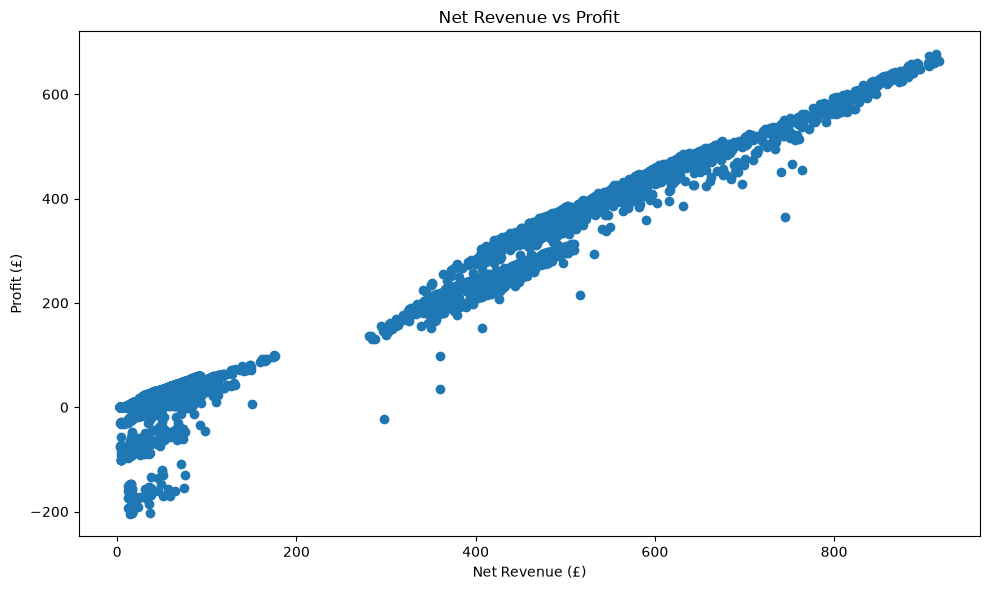

,net_revenue_gbp,profit_gbp
0,21.36,5.70
1,403.61,288.43
2,10.83,2.26
3,57.83,34.55
4,36.62,14.91


In [26]:
profit_scatter = df[["net_revenue_gbp", "profit_gbp"]].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(profit_scatter["net_revenue_gbp"], profit_scatter["profit_gbp"])
plt.title("Net Revenue vs Profit")
plt.xlabel("Net Revenue (£)")
plt.ylabel("Profit (£)")
plt.tight_layout()
plt.show()

profit_scatter.head()

Business Summary & Dataset Metadata

In [36]:
import numpy as np

monthly = (
    df.set_index("transaction_date")
      .resample("MS")["net_revenue_gbp"]
      .sum()
)

dec_mom = (
    (monthly.loc["2025-12-01"] - monthly.loc["2025-11-01"])
    / monthly.loc["2025-11-01"] * 100
)

northside = (
    df[df["branch"] == "Northside"]
    .set_index("transaction_date")
    .resample("MS")["net_revenue_gbp"]
    .sum()
)

northside_mom = (
    (northside.loc["2025-12-01"] - northside.loc["2025-11-01"])
    / northside.loc["2025-11-01"] * 100
)

anomaly_check = monthly.to_frame("observed")
anomaly_check["expected"] = (
    anomaly_check["observed"]
    .shift(1)
    .rolling(12)
    .median()
)

anomaly_check["above_expected_pct"] = (
    (anomaly_check["observed"] - anomaly_check["expected"])
    / anomaly_check["expected"] * 100
)

anomaly_check = anomaly_check.loc[
    ["2025-01-01", "2025-09-01"]
].reset_index()

forecast_df["timestamp"] = pd.to_datetime(forecast_df["timestamp"])

if "predictions" in forecast_df.columns:
    forecast_col = "predictions"
elif "0.5" in forecast_df.columns:
    forecast_col = "0.5"
else:
    forecast_col = 0.5

jan_2026 = forecast_df.loc[
    forecast_df["timestamp"].dt.to_period("M") == pd.Period("2026-01"),
    forecast_col
].iloc[0]

checks = pd.DataFrame([
    {
        "Claim": "Dataset covers 2015–2025",
        "Calculated": f"{df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}",
        "Reported": "2015–2025",
        "Match": df["transaction_date"].min().year == 2015 and df["transaction_date"].max().year == 2025
    },
    {
        "Claim": "Dec 2025 total net revenue MoM",
        "Calculated": f"{dec_mom:.2f}%",
        "Reported": "-18.66%",
        "Match": np.isclose(dec_mom, -18.66, atol=0.01)
    },
    {
        "Claim": "Dec 2025 Northside MoM",
        "Calculated": f"+{northside_mom:.2f}%",
        "Reported": "+9.16%",
        "Match": np.isclose(northside_mom, 9.16, atol=0.01)
    },
    {
        "Claim": "Jan 2026 forecast",
        "Calculated": f"£{jan_2026:,.2f}",
        "Reported": "~£48,700",
        "Match": np.isclose(jan_2026, 48700, atol=1000)
    }
])

display(checks)

display(
    anomaly_check.rename(columns={
        "transaction_date": "Month",
        "observed": "Observed Revenue (£)",
        "expected": "12-Month Expected Revenue (£)",
        "above_expected_pct": "Above Expected (%)"
    })
)

display(
    forecast_df[
        ["timestamp", forecast_col]
    ].head(6).rename(columns={
        "timestamp": "Month",
        forecast_col: "Forecast Revenue (£)"
    })
)

missing_values_df = pd.DataFrame({
    "Metric": ["Total Missing Values"],
    "Value": [df.isna().sum().sum()]
})

display(missing_values_df)

,Claim,Calculated,Reported,Match
0,Dataset covers 2015–2025,2015-01-01 to 2025-12-31,2015–2025,True
1,Dec 2025 total net revenue MoM,-18.66%,-18.66%,True
2,Dec 2025 Northside MoM,+9.16%,+9.16%,True
3,Jan 2026 forecast,"£48,598.77","~£48,700",True


,Month,Observed Revenue (£),12-Month Expected Revenue (£),Above Expected (%)
0,2025-01-01,61321.68,20524.820,198.768418
1,2025-09-01,38898.90,25735.155,51.150829


,Month,Forecast Revenue (£)
0,2026-01-01,48598.765625
1,2026-02-01,39908.792969
2,2026-03-01,38675.593750
3,2026-04-01,37139.589844
4,2026-05-01,34938.667969
5,2026-06-01,29450.921875


,Metric,Value
0,Total Missing Values,80
